In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import requests

#Um Dashboard Inteligente Com Dados Climáticos DAS Capitais Do Brasil

#AGEMC
- ASK
- Get
- Explorer
- Model
- Communicate

In [2]:
# Fazendo uma requisição HTML

url = "https://api.open-meteo.com/v1/forecast"

In [41]:
def obter_dados_climaticos(latitude:float, longitude: float)-> pd.DataFrame:

    """Uma função que recupera dados de uma API climática
    \"https://api.open-meteo.com/v1/forecast\" e os devolve em um
    DataFrame"""


    URL_API = "https://api.open-meteo.com/v1/forecast"

    # As informações que eu quero
    hourly = ["temperature_2m", "relative_humidity_2m"]


    # Parametros
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": hourly,
        "timezone": "auto"
    }


    # Requisição realizada e resposta
    response = requests.get(URL_API, params= params)

    # response.raise_for_status()

    data = response.json()

    # Estruturação dos dados em DataFrame

    # print(data)

    return pd.DataFrame({
        "data_hora": pd.to_datetime(data["hourly"]["time"]),
        "temperature_celsius": data["hourly"]["temperature_2m"],
        "relative_humidity": data["hourly"]["relative_humidity_2m"]
    })


In [42]:
latitudes = [
    {
        "state": "SP",
        "city": "São Paulo",
        "lat": -23.33,
        "long": -46.38
    },
    {
        "state": "GO",
        "city": "Goiânia",
        "lat": -16.40,
        "long": -49.15
    }
]

In [43]:
df_sp = obter_dados_climaticos(-23.33, -46.38)

In [44]:
df_sp.head()

,data_hora,temperature_celsius,relative_humidity
0,2026-09-14 00:00:00,12.5,100
1,2026-09-14 01:00:00,12.4,100
2,2026-09-14 02:00:00,12.3,99
3,2026-09-14 03:00:00,12.3,100
4,2026-09-14 04:00:00,12.3,100


In [45]:
df_sp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data_hora            168 non-null    datetime64[ns]
 1   temperature_celsius  168 non-null    float64       
 2   relative_humidity    168 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 4.1 KB


In [46]:
df_sp["data"] = df_sp["data_hora"].dt.date

In [27]:
df_sp.head()

,data_hora,temperature_celsius,relative_humidity,data
0,2026-09-14 00:00:00,12.5,100,2026-09-14
1,2026-09-14 01:00:00,12.4,100,2026-09-14
2,2026-09-14 02:00:00,12.3,99,2026-09-14
3,2026-09-14 03:00:00,12.3,100,2026-09-14
4,2026-09-14 04:00:00,12.3,100,2026-09-14


In [47]:
df_sp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data_hora            168 non-null    datetime64[ns]
 1   temperature_celsius  168 non-null    float64       
 2   relative_humidity    168 non-null    int64         
 3   data                 168 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 5.4+ KB


In [69]:
df_sp = df_sp.drop(columns= ["data"])

In [82]:
temperatura_sp_hoje = df_sp[df_sp["data_hora"].dt.date == datetime.date(2026,9,14)].copy()

In [71]:
temperatura_sp_hoje

,data_hora,temperature_celsius,relative_humidity
0,2026-09-14 00:00:00,12.5,100
1,2026-09-14 01:00:00,12.4,100
2,2026-09-14 02:00:00,12.3,99
3,2026-09-14 03:00:00,12.3,100
4,2026-09-14 04:00:00,12.3,100
5,2026-09-14 05:00:00,12.3,100
6,2026-09-14 06:00:00,12.3,100
7,2026-09-14 07:00:00,12.3,99
8,2026-09-14 08:00:00,12.5,99
9,2026-09-14 09:00:00,13.9,94


In [57]:
import datetime

In [56]:
df_sp["data"].unique()

array([datetime.date(2026, 9, 14), datetime.date(2026, 9, 15),
       datetime.date(2026, 9, 16), datetime.date(2026, 9, 17),
       datetime.date(2026, 9, 18), datetime.date(2026, 9, 19),
       datetime.date(2026, 9, 20)], dtype=object)

In [58]:
set(df_sp["data"] == datetime.date(2026, 9, 14))

{False, True}

In [ ]:
df_sp["data_hora"]

#Qual o objetivo deste projeto:
- Entregar um dashboard online com dados climáticos de três principais capitais do Brasil  

#5W2h

- Oque?
- Porque?
- Quando?
- Como?
- Onde?
- Quem?
- Quanto Custa?

In [61]:
temperatura_sp_hoje.columns

Index(['data_hora', 'temperature_celsius', 'relative_humidity', 'data'], dtype='object')

In [78]:
sns.set_style("darkgrid")

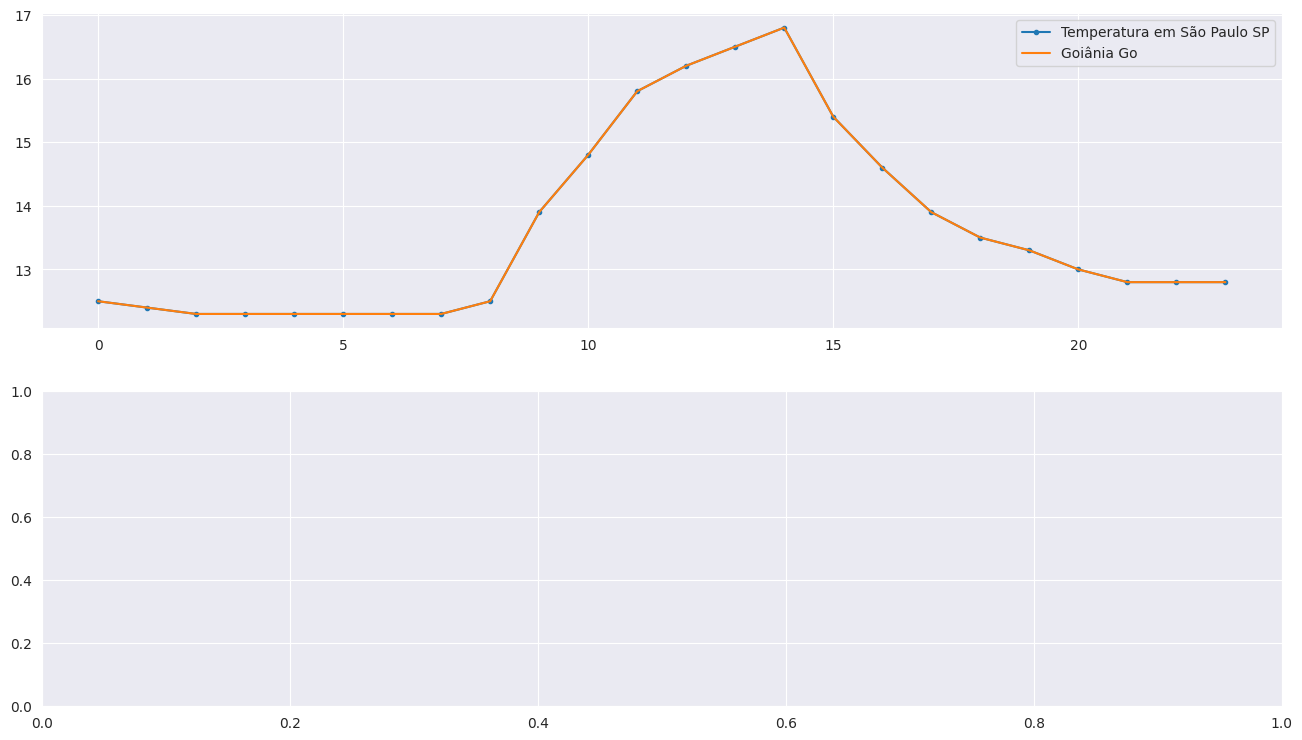

In [139]:
# plt.figure(figsize= (16, 4))

fig, axes = plt.subplots(2, 1, figsize= (16, 9), squeeze= False)


axes[0, 0].plot(temperatura_sp_hoje["data_hora"].dt.hour,
         temperatura_sp_hoje["temperature_celsius"],
         marker= ".")

axes[0, 0].plot(temperatura_sp_hoje["data_hora"].dt.hour,
             temperatura_sp_hoje["temperature_celsius"])

axes[0, 0].legend(["Temperatura em São Paulo SP", "Goiânia Go"])

# plt.tight_layout(pad= 2)
